# Chapter 4: Regression and Prediction
> (c) 2019-2026 Peter C. Bruce, Andrew Bruce, Peter Gedeck

In [1]:
library(MASS)
library(latex2exp)
library(lubridate)
library(mgcv)
library(splines)
library(tidyverse)

set.seed(123)

# Location of the data files. Adjust this path if you keep the data
# files in a different directory.
DATA_DIR <- '../../data'



Attaching package: ‘lubridate’




The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union




Loading required package: nlme



This is mgcv 1.9-4. For overview type '?mgcv'.



── Attaching core tidyverse packages ───────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr   1.2.1     ✔ readr   2.2.0
✔ forcats 1.0.1     ✔ stringr 1.6.0
✔ ggplot2 4.0.2     ✔ tibble  3.3.1
✔ purrr   1.2.2     ✔ tidyr   1.3.2


── Conflicts ─────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::collapse() masks nlme::collapse()
✖ dplyr::filter()   masks stats::filter()
✖ dplyr::lag()      masks stats::lag()
✖ dplyr::select()   masks MASS::select()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


## Regression and Prediction
### Simple Linear Regression
#### The Regression Equation

In [1]:
lung <- read_csv(file.path(DATA_DIR, "LungDisease.csv"))
model <- lm(PEFR ~ Exposure, data = lung)

Rows: 122 Columns: 2


── Column specification ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
dbl (2): PEFR, Exposure



ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [1]:
PEFR ~ Exposure - 1

PEFR ~ Exposure - 1

In [1]:
model


Call:
lm(formula = PEFR ~ Exposure, data = lung)

Coefficients:
(Intercept)     Exposure  
    424.583       -4.185  


#### Fitted Values and Residuals

In [1]:
fitted <- predict(model)
resid <- residuals(model)

### Multiple Linear Regression
#### Example: King County Housing Data

In [1]:
house <- read_csv(file.path(DATA_DIR, "house_sales.csv"), show_col_types = FALSE)
head(house[, c("AdjSalePrice", "SqFtTotLiving", "SqFtLot", "Bathrooms",
      "Bedrooms", "BldgGrade")])

AdjSalePrice,SqFtTotLiving,SqFtLot,Bathrooms,Bedrooms,BldgGrade
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
300805,2400,9373,3.00,6,7
1076162,3764,20156,3.75,4,10
761805,2060,26036,1.75,4,8
442065,3200,8618,3.75,5,7
297065,1720,8620,1.75,4,7
411781,930,1012,1.50,2,8


In [1]:
house_lm <- lm(AdjSalePrice ~ SqFtTotLiving + SqFtLot + Bathrooms +
    Bedrooms + BldgGrade,
  data = house, na.action = na.omit)

In [1]:
house_lm


Call:
lm(formula = AdjSalePrice ~ SqFtTotLiving + SqFtLot + Bathrooms + 
    Bedrooms + BldgGrade, data = house, na.action = na.omit)

Coefficients:
  (Intercept)  SqFtTotLiving        SqFtLot      Bathrooms       Bedrooms  
   -5.219e+05      2.288e+02     -6.047e-02     -1.944e+04     -4.777e+04  
    BldgGrade  
    1.061e+05  


#### Assessing the Model

In [1]:
summary(house_lm)


Call:
lm(formula = AdjSalePrice ~ SqFtTotLiving + SqFtLot + Bathrooms + 
    Bedrooms + BldgGrade, data = house, na.action = na.omit)

Residuals:
     Min       1Q   Median       3Q      Max 
-1199479  -118908   -20977    87435  9473035 

Coefficients:
                Estimate Std. Error t value Pr(>|t|)    
(Intercept)   -5.219e+05  1.565e+04 -33.342  < 2e-16 ***
SqFtTotLiving  2.288e+02  3.899e+00  58.694  < 2e-16 ***
SqFtLot       -6.047e-02  6.118e-02  -0.988    0.323    
Bathrooms     -1.944e+04  3.625e+03  -5.363 8.27e-08 ***
Bedrooms      -4.777e+04  2.490e+03 -19.187  < 2e-16 ***
BldgGrade      1.061e+05  2.396e+03  44.277  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 261300 on 22681 degrees of freedom
Multiple R-squared:  0.5406,	Adjusted R-squared:  0.5405 
F-statistic:  5338 on 5 and 22681 DF,  p-value: < 2.2e-16


#### Model Selection and Stepwise Regression

In [1]:
house_full <- lm(AdjSalePrice ~ SqFtTotLiving + SqFtLot + Bathrooms +
    Bedrooms + BldgGrade + PropertyType + NbrLivingUnits +
    SqFtFinBasement + YrBuilt + YrRenovated + NewConstruction,
  data = house, na.action = na.omit)

In [1]:
step_lm <- stepAIC(house_full, direction = "both")
step_lm

Start:  AIC=563145.4
AdjSalePrice ~ SqFtTotLiving + SqFtLot + Bathrooms + Bedrooms + 
    BldgGrade + PropertyType + NbrLivingUnits + SqFtFinBasement + 
    YrBuilt + YrRenovated + NewConstruction



                  Df  Sum of Sq        RSS    AIC
- NbrLivingUnits   1 6.4007e+09 1.3662e+15 563144
- NewConstruction  1 1.0592e+10 1.3662e+15 563144
- YrRenovated      1 2.5069e+10 1.3662e+15 563144
- SqFtLot          1 1.0657e+11 1.3663e+15 563145
<none>                          1.3662e+15 563145
- SqFtFinBasement  1 1.4030e+11 1.3663e+15 563146
- PropertyType     2 4.4207e+12 1.3706e+15 563215
- Bathrooms        1 7.6325e+12 1.3738e+15 563270
- Bedrooms         1 2.8212e+13 1.3944e+15 563607
- YrBuilt          1 1.2906e+14 1.4952e+15 565191
- SqFtTotLiving    1 1.3264e+14 1.4988e+15 565246
- BldgGrade        1 1.9050e+14 1.5567e+15 566105



Step:  AIC=563143.6
AdjSalePrice ~ SqFtTotLiving + SqFtLot + Bathrooms + Bedrooms + 
    BldgGrade + PropertyType + SqFtFinBasement + YrBuilt + YrRenovated + 
    NewConstruction



                  Df  Sum of Sq        RSS    AIC
- NewConstruction  1 1.0801e+10 1.3662e+15 563142
- YrRenovated      1 2.5628e+10 1.3662e+15 563142
- SqFtLot          1 1.0731e+11 1.3663e+15 563143
<none>                          1.3662e+15 563144
- SqFtFinBasement  1 1.3828e+11 1.3663e+15 563144
+ NbrLivingUnits   1 6.4007e+09 1.3662e+15 563145
- PropertyType     2 4.4301e+12 1.3706e+15 563213
- Bathrooms        1 7.7500e+12 1.3739e+15 563270
- Bedrooms         1 2.8273e+13 1.3944e+15 563606
- YrBuilt          1 1.3013e+14 1.4963e+15 565206
- SqFtTotLiving    1 1.3288e+14 1.4990e+15 565247
- BldgGrade        1 1.9177e+14 1.5579e+15 566122



Step:  AIC=563141.7
AdjSalePrice ~ SqFtTotLiving + SqFtLot + Bathrooms + Bedrooms + 
    BldgGrade + PropertyType + SqFtFinBasement + YrBuilt + YrRenovated



...


Step:  AIC=563140.2
AdjSalePrice ~ SqFtTotLiving + SqFtLot + Bathrooms + Bedrooms + 
    BldgGrade + PropertyType + SqFtFinBasement + YrBuilt



                  Df  Sum of Sq        RSS    AIC
- SqFtLot          1 1.1425e+11 1.3663e+15 563140
<none>                          1.3662e+15 563140
- SqFtFinBasement  1 1.4999e+11 1.3664e+15 563141
+ YrRenovated      1 2.5893e+10 1.3662e+15 563142
+ NewConstruction  1 1.1065e+10 1.3662e+15 563142
+ NbrLivingUnits   1 7.1825e+09 1.3662e+15 563142
- PropertyType     2 4.5076e+12 1.3707e+15 563211
- Bathrooms        1 7.7790e+12 1.3740e+15 563267
- Bedrooms         1 2.8251e+13 1.3945e+15 563603
- SqFtTotLiving    1 1.3388e+14 1.5001e+15 565259
- YrBuilt          1 1.5091e+14 1.5171e+15 565515
- BldgGrade        1 1.9244e+14 1.5587e+15 566128



Step:  AIC=563140.1
AdjSalePrice ~ SqFtTotLiving + Bathrooms + Bedrooms + BldgGrade + 
    PropertyType + SqFtFinBasement + YrBuilt



                  Df  Sum of Sq        RSS    AIC
<none>                          1.3663e+15 563140
+ SqFtLot          1 1.1425e+11 1.3662e+15 563140
- SqFtFinBasement  1 1.4116e+11 1.3665e+15 563140
+ YrRenovated      1 2.5199e+10 1.3663e+15 563142
+ NewConstruction  1 1.8750e+10 1.3663e+15 563142
+ NbrLivingUnits   1 8.0521e+09 1.3663e+15 563142
- PropertyType     2 4.4415e+12 1.3708e+15 563210
- Bathrooms        1 7.7109e+12 1.3740e+15 563266
- Bedrooms         1 2.8553e+13 1.3949e+15 563607
- SqFtTotLiving    1 1.3748e+14 1.5038e+15 565313
- YrBuilt          1 1.5080e+14 1.5171e+15 565513
- BldgGrade        1 1.9234e+14 1.5587e+15 566126



Call:
lm(formula = AdjSalePrice ~ SqFtTotLiving + Bathrooms + Bedrooms + 
    BldgGrade + PropertyType + SqFtFinBasement + YrBuilt, data = house, 
    na.action = na.omit)

Coefficients:
              (Intercept)              SqFtTotLiving  
                6.179e+06                  1.993e+02  
                Bathrooms                   Bedrooms  
                4.240e+04                 -5.195e+04  
                BldgGrade  PropertyTypeSingle Family  
                1.372e+05                  2.291e+04  
    PropertyTypeTownhouse            SqFtFinBasement  
                8.448e+04                  7.047e+00  
                  YrBuilt  
               -3.565e+03  


#### Weighted Regression

In [1]:
house$Year <- year(parse_date_time(house$DocumentDate, "m/d/y"))
house$Weight <- house$Year - 2005

In [1]:
house_wt <- lm(AdjSalePrice ~ SqFtTotLiving + SqFtLot + Bathrooms +
    Bedrooms + BldgGrade,
  data = house, weight = Weight)
round(cbind(house_lm = house_lm$coefficients,
    house_wt = house_wt$coefficients), digits = 3)

,house_lm,house_wt
(Intercept),-521871.368,-584189.329
SqFtTotLiving,228.831,245.024
SqFtLot,-0.060,-0.292
Bathrooms,-19442.840,-26085.970
Bedrooms,-47769.955,-53608.876
BldgGrade,106106.963,115242.435


### Factor Variables in Regression
#### Dummy Variables Representation

In [1]:
head(house[, "PropertyType"])

PropertyType
<chr>
Multiplex
Single Family
Single Family
Single Family
Single Family
Townhouse


In [1]:
prop_type_dummies <- model.matrix(~ PropertyType - 1, data = house)
head(prop_type_dummies)

,PropertyTypeMultiplex,PropertyTypeSingle Family,PropertyTypeTownhouse
1,1,0,0
2,0,1,0
3,0,1,0
4,0,1,0
5,0,1,0
6,0,0,1


In [1]:
lm(AdjSalePrice ~ SqFtTotLiving + SqFtLot + Bathrooms +
    Bedrooms + BldgGrade + PropertyType, data = house)


Call:
lm(formula = AdjSalePrice ~ SqFtTotLiving + SqFtLot + Bathrooms + 
    Bedrooms + BldgGrade + PropertyType, data = house)

Coefficients:
              (Intercept)              SqFtTotLiving  
               -4.468e+05                  2.234e+02  
                  SqFtLot                  Bathrooms  
               -7.037e-02                 -1.598e+04  
                 Bedrooms                  BldgGrade  
               -5.089e+04                  1.094e+05  
PropertyTypeSingle Family      PropertyTypeTownhouse  
               -8.468e+04                 -1.151e+05  


#### Factor Variables with Many Levels

In [1]:
table(house$ZipCode)


98001 98002 98003 98004 98005 98006 98007 98008 98010 98011 98014 98019 98022 
  358   180   241   293   133   460   112   291    56   163    85   242   188 
98023 98024 98027 98028 98029 98030 98031 98032 98033 98034 98038 98039 98040 
  455    31   366   252   475   263   308   121   517   575   788    47   244 
98042 98043 98045 98047 98050 98051 98052 98053 98055 98056 98057 98058 98059 
  641     1   222    48     7    32   614   499   332   402     4   420   513 
98065 98068 98070 98072 98074 98075 98077 98092 98102 98103 98105 98106 98107 
  430     1    89   245   502   388   204   289   106   671   313   361   296 
98108 98109 98112 98113 98115 98116 98117 98118 98119 98122 98125 98126 98133 
  155   149   357     1   620   364   619   492   260   380   409   473   465 
98136 98144 98146 98148 98155 98166 98168 98177 98178 98188 98198 98199 98224 
  310   332   287    40   358   193   332   216   266   101   225   393     3 
98288 98354 
    4     9 

In [1]:
zip_groups <- house %>%
  mutate(resid = residuals(house_lm)) %>%
  group_by(ZipCode) %>%
  summarize(med_resid = median(resid), cnt = n()) %>%
  arrange(med_resid) %>%
  mutate(
    cum_cnt = cumsum(cnt),
    ZipGroup = ntile(cum_cnt, 5),
  ) %>%
  select(ZipCode, ZipGroup)
house <- house %>%
  left_join(zip_groups, by = "ZipCode") %>%
  mutate(ZipGroup = as.factor(ZipGroup))

In [1]:
table(zip_groups[c("ZipGroup")])

ZipGroup
 1  2  3  4  5 
16 16 16 16 16 

### Interpreting the Regression Equation
#### Correlated Predictors

In [1]:
step_lm$coefficients

(Intercept)             SqFtTotLiving                 Bathrooms 
             6.178645e+06              1.992776e+02              4.239616e+04 
                 Bedrooms                 BldgGrade PropertyTypeSingle Family 
            -5.194738e+04              1.371596e+05              2.291206e+04 
    PropertyTypeTownhouse           SqFtFinBasement                   YrBuilt 
             8.447916e+04              7.046975e+00             -3.565425e+03

In [1]:
update(step_lm, . ~ . - SqFtTotLiving - SqFtFinBasement - Bathrooms)


Call:
lm(formula = AdjSalePrice ~ Bedrooms + BldgGrade + PropertyType + 
    YrBuilt, data = house, na.action = na.omit)

Coefficients:
              (Intercept)                   Bedrooms  
                  4913973                      27151  
                BldgGrade  PropertyTypeSingle Family  
                   248998                     -19898  
    PropertyTypeTownhouse                    YrBuilt  
                   -47355                      -3212  


#### Confounding Variables

In [1]:
lm(AdjSalePrice ~ SqFtTotLiving + SqFtLot + Bathrooms +
    Bedrooms + BldgGrade + PropertyType + ZipGroup, data = house,
  na.action = na.omit)


Call:
lm(formula = AdjSalePrice ~ SqFtTotLiving + SqFtLot + Bathrooms + 
    Bedrooms + BldgGrade + PropertyType + ZipGroup, data = house, 
    na.action = na.omit)

Coefficients:
              (Intercept)              SqFtTotLiving  
               -6.666e+05                  2.106e+02  
                  SqFtLot                  Bathrooms  
                4.550e-01                  5.928e+03  
                 Bedrooms                  BldgGrade  
               -4.168e+04                  9.854e+04  
PropertyTypeSingle Family      PropertyTypeTownhouse  
                1.932e+04                 -7.820e+04  
                ZipGroup2                  ZipGroup3  
                5.332e+04                  1.163e+05  
                ZipGroup4                  ZipGroup5  
                1.784e+05                  3.384e+05  


#### Interactions and Main Effects

In [1]:
lm(formula = AdjSalePrice ~ SqFtTotLiving * ZipGroup + SqFtLot +
    Bathrooms + Bedrooms + BldgGrade + PropertyType, data = house,
  na.action = na.omit)


Call:
lm(formula = AdjSalePrice ~ SqFtTotLiving * ZipGroup + SqFtLot + 
    Bathrooms + Bedrooms + BldgGrade + PropertyType, data = house, 
    na.action = na.omit)

Coefficients:
              (Intercept)              SqFtTotLiving  
               -4.853e+05                  1.148e+02  
                ZipGroup2                  ZipGroup3  
               -1.113e+04                  2.032e+04  
                ZipGroup4                  ZipGroup5  
                2.050e+04                 -1.499e+05  
                  SqFtLot                  Bathrooms  
                6.869e-01                 -3.619e+03  
                 Bedrooms                  BldgGrade  
               -4.180e+04                  1.047e+05  
PropertyTypeSingle Family      PropertyTypeTownhouse  
                1.357e+04                 -5.884e+04  
  SqFtTotLiving:ZipGroup2    SqFtTotLiving:ZipGroup3  
                3.260e+01                  4.178e+01  
  SqFtTotLiving:ZipGroup4    SqFtTotLiving:ZipGro

### Regression Diagnostics
#### Outliers

In [1]:
house_98105 <- house %>% filter(ZipCode == 98105)
lm_98105 <- lm(AdjSalePrice ~ SqFtTotLiving + SqFtLot + Bathrooms +
    Bedrooms + BldgGrade, data = house_98105)

In [1]:
sresid <- rstandard(lm_98105)
idx <- order(sresid)
sresid[idx[1]]

259 
-4.326732

In [1]:
house_98105[idx[1], c("AdjSalePrice", "SqFtTotLiving", "SqFtLot",
    "Bathrooms", "Bedrooms", "BldgGrade")]

AdjSalePrice,SqFtTotLiving,SqFtLot,Bathrooms,Bedrooms,BldgGrade
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
119748,2900,7276,3,6,7


#### Influential Values

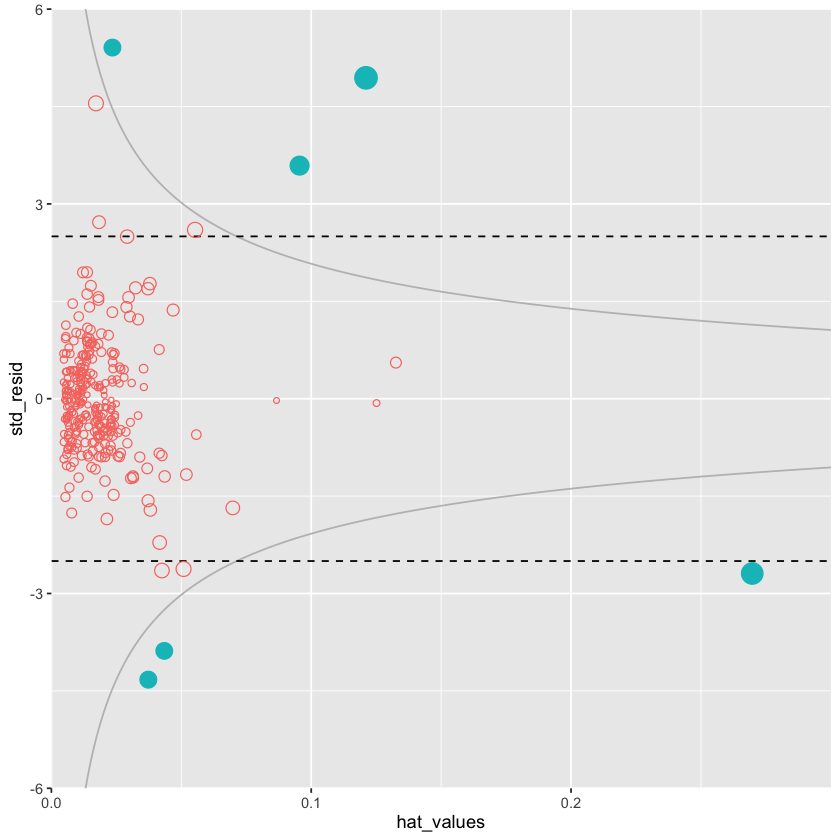

In [1]:
df_influential <- tibble(
  std_resid = rstandard(lm_98105),
  cooks_d = cooks.distance(lm_98105),
  hat_values = hatvalues(lm_98105),
)

p <- 6 # Number of model parameters (e.g., intercept + 2 predictors)
D_i <- 0.08 # Target Cook's Distance
cooks_curve_data <- tibble(
  t = seq(-10, 10, length.out = 1000),
  cooks_d = 0.08,
) %>%
  mutate(
    hat_values = 1 / (1 + t^2),
    std_resid = sqrt(D_i * p) * t
  )

ggplot(df_influential, aes(x = hat_values, y = std_resid,
    color = cooks_d > 0.08, shape = cooks_d > 0.08)) +
  geom_path(aes(size = NULL, color = NULL, shape = NULL),
    data = cooks_curve_data, color = "grey", linewidth = 0.5) +
  geom_hline(yintercept = c(-2.5, 2.5), linetype = 2) +
  geom_point(aes(size = 10 * sqrt(cooks_d))) +
  scale_shape_manual(values = c(1, 19)) +
  guides(color = "none", shape = "none", size = "none") +
  coord_cartesian(xlim = c(0, 0.3), ylim = c(-6, 6), expand = FALSE)

#### Heteroskedasticity, Nonnormality, and Correlated Errors

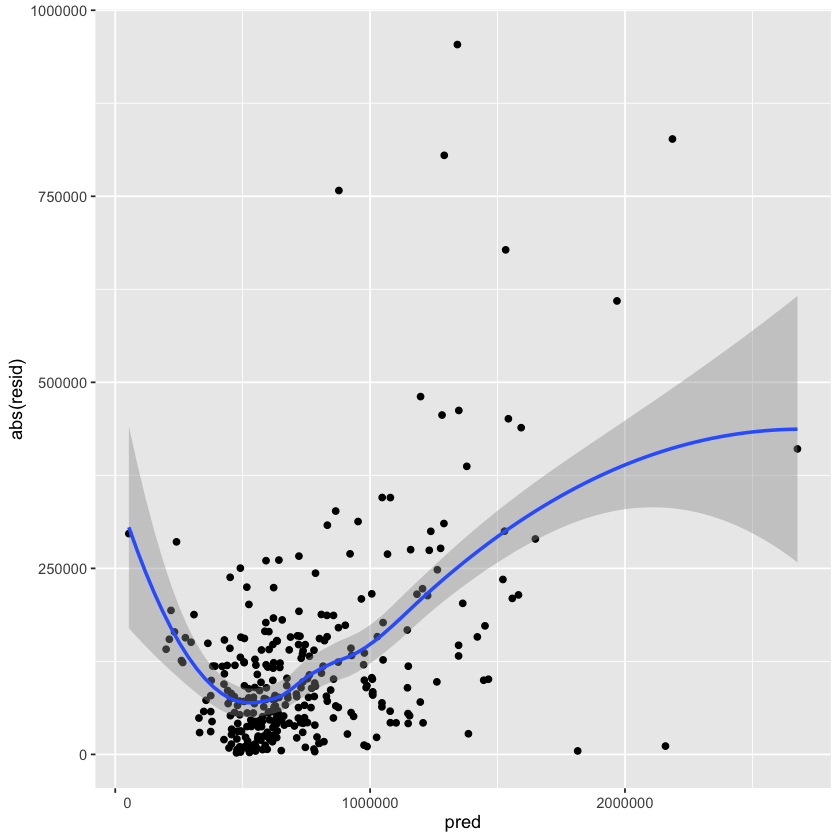

In [1]:
df <- data.frame(resid = residuals(lm_98105), pred = predict(lm_98105))
ggplot(df, aes(x = pred, y = abs(resid))) +
  geom_point() +
  geom_smooth(formula = y ~ x, method = "loess") +
  scale_x_continuous(labels = function(x) format(x, scientific = FALSE))

#### Partial Residual Plots and Nonlinearity

In [1]:
terms <- predict(lm_98105, type = "terms")
partial_resid <- resid(lm_98105) + terms

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


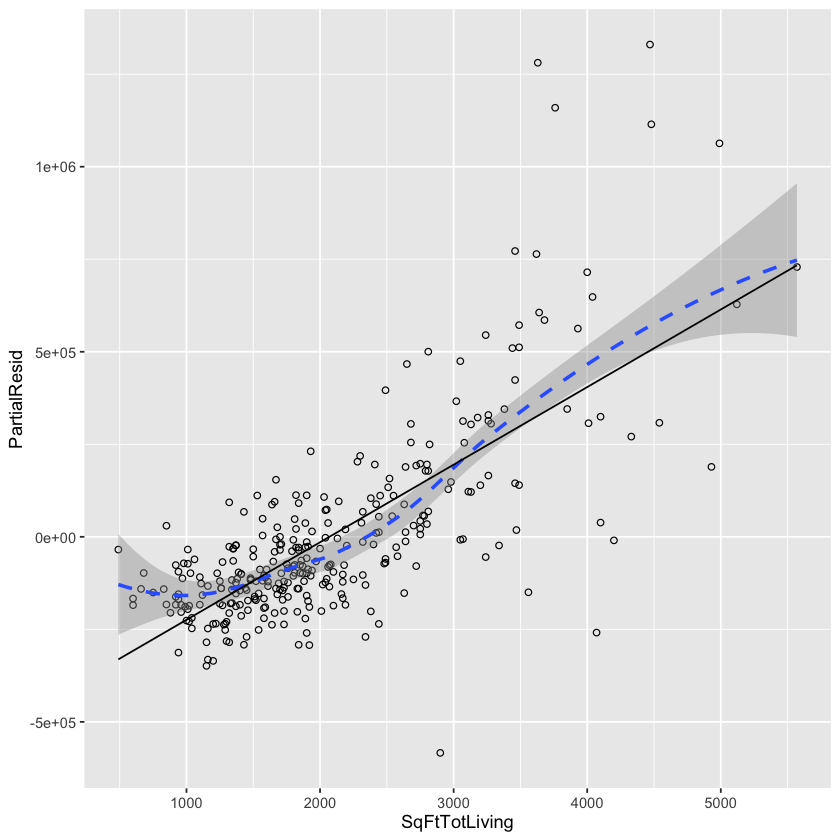

In [1]:
df <- data.frame(SqFtTotLiving = house_98105[, "SqFtTotLiving"],
  Terms = terms[, "SqFtTotLiving"],
  PartialResid = partial_resid[, "SqFtTotLiving"])
ggplot(df, aes(SqFtTotLiving, PartialResid)) +
  geom_point(shape = 1) +
  scale_shape(solid = FALSE) +
  geom_smooth(linetype = 2) +
  geom_line(aes(SqFtTotLiving, Terms))

### Polynomial and Spline Regression
#### Polynomial

In [1]:
lm_poly <- lm(AdjSalePrice ~ poly(SqFtTotLiving, 2) + SqFtLot +
    BldgGrade + Bathrooms + Bedrooms, data = house_98105)
lm_poly


Call:
lm(formula = AdjSalePrice ~ poly(SqFtTotLiving, 2) + SqFtLot + 
    BldgGrade + Bathrooms + Bedrooms, data = house_98105)

Coefficients:
            (Intercept)  poly(SqFtTotLiving, 2)1  poly(SqFtTotLiving, 2)2  
             -402530.47               3271519.49                776934.02  
                SqFtLot                BldgGrade                Bathrooms  
                  32.56                135717.06                 -1435.12  
               Bedrooms  
               -9191.94  


#### Splines

In [1]:
knots <- quantile(house_98105$SqFtTotLiving, p = c(0.25, 0.5, 0.75))
lm_spline <- lm(AdjSalePrice ~ bs(SqFtTotLiving, knots = knots, degree = 3) +
    SqFtLot + Bathrooms + Bedrooms + BldgGrade,
  data = house_98105)
lm_spline


Call:
lm(formula = AdjSalePrice ~ bs(SqFtTotLiving, knots = knots, 
    degree = 3) + SqFtLot + Bathrooms + Bedrooms + BldgGrade, 
    data = house_98105)

Coefficients:
                                  (Intercept)  
                                   -414157.61  
bs(SqFtTotLiving, knots = knots, degree = 3)1  
                                   -199529.76  
bs(SqFtTotLiving, knots = knots, degree = 3)2  
                                   -120580.64  
bs(SqFtTotLiving, knots = knots, degree = 3)3  
                                    -71644.39  
bs(SqFtTotLiving, knots = knots, degree = 3)4  
                                    195677.89  
bs(SqFtTotLiving, knots = knots, degree = 3)5  
                                    845244.25  
bs(SqFtTotLiving, knots = knots, degree = 3)6  
                                    695545.67  
                                      SqFtLot  
                                        33.33  
                                    Bathrooms  
             

#### Generalized Additive Models

In [1]:
lm_gam <- gam(AdjSalePrice ~ s(SqFtTotLiving) + SqFtLot +
    Bathrooms + Bedrooms + BldgGrade, data = house_98105)
lm_gam


Family: gaussian 
Link function: identity 

Formula:
AdjSalePrice ~ s(SqFtTotLiving) + SqFtLot + Bathrooms + Bedrooms + 
    BldgGrade

Estimated degrees of freedom:
4.49  total = 9.49 

GCV score: 30148051324     

# Supplementary Material
## Figure 4-1. Cotton exposure versus lung capacity

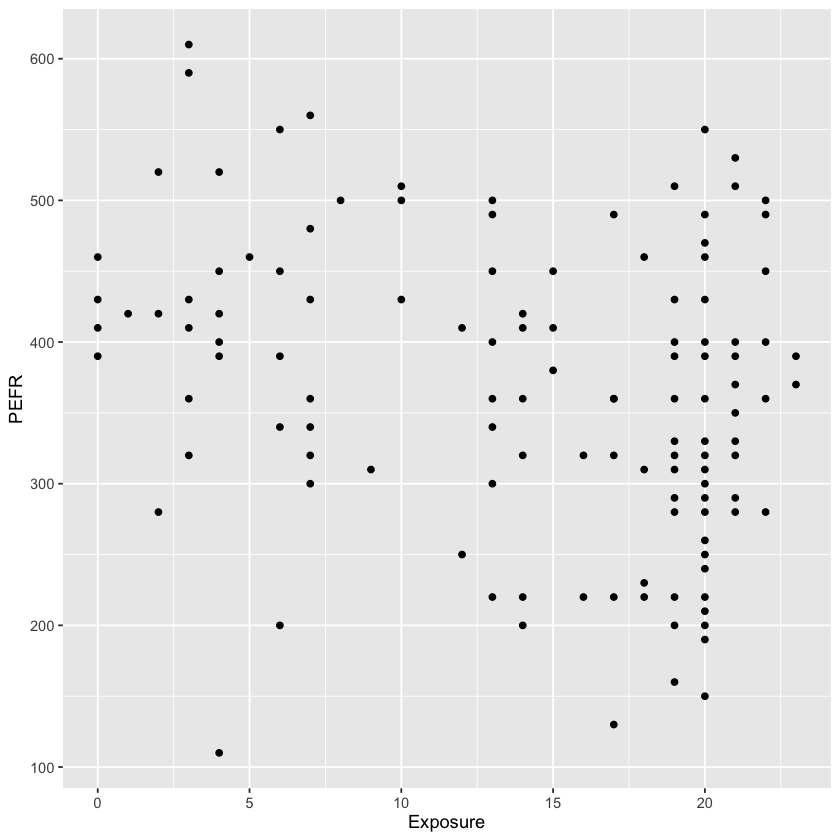

In [1]:
lung <- read_csv(file.path(DATA_DIR, "LungDisease.csv"), show_col_types = FALSE)
ggplot(lung, aes(x = Exposure, y = PEFR)) +
  geom_point()

## Figure 4-2. Slope and intercept for the regression fit to the lung data

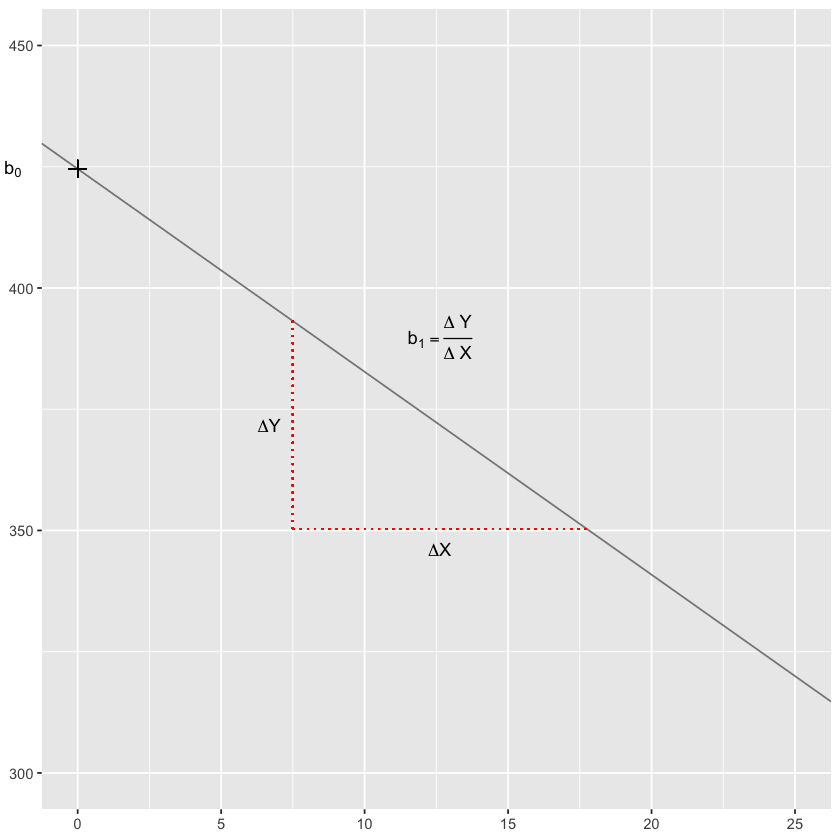

In [1]:
model <- lm(PEFR ~ Exposure, data = lung)
x <- c(7.5, 17.75)
y <- predict(model, newdata = data.frame(Exposure = x))

ggplot(lung, aes(x = Exposure, y = PEFR)) +
  geom_abline(intercept = model$coefficients[1], slope = model$coefficients[2],
    color = "#888888") +
  coord_cartesian(xlim = c(0, 25), ylim = c(300, 450), clip = "off") +
  geom_point(x = 0, y = model$coefficients[1], shape = 3, size = 3) +
  annotate("text", -2.25, model$coefficients[1], label = TeX("$b_0$")) +
  geom_segment(x = x[1], y = y[2], xend = x[2], yend = y[2],
    color = "red", linetype = 3) +
  geom_segment(x = x[1], y = y[1], xend = x[1], yend = y[2],
    color = "red", linetype = 3) +
  annotate("text", x = x[1], y = mean(y), label = TeX("$Delta Y$"),
    hjust = 1.5) +
  annotate("text", x = mean(x), y = y[2], label = TeX("$Delta X$"),
    vjust = 2) +
  annotate("text", x = mean(x), y = 390, label = TeX("$b_1 = \\frac{Delta~Y}{Delta~X}$"))

## Figure 4-3. Residuals for the regression fit to the lung data

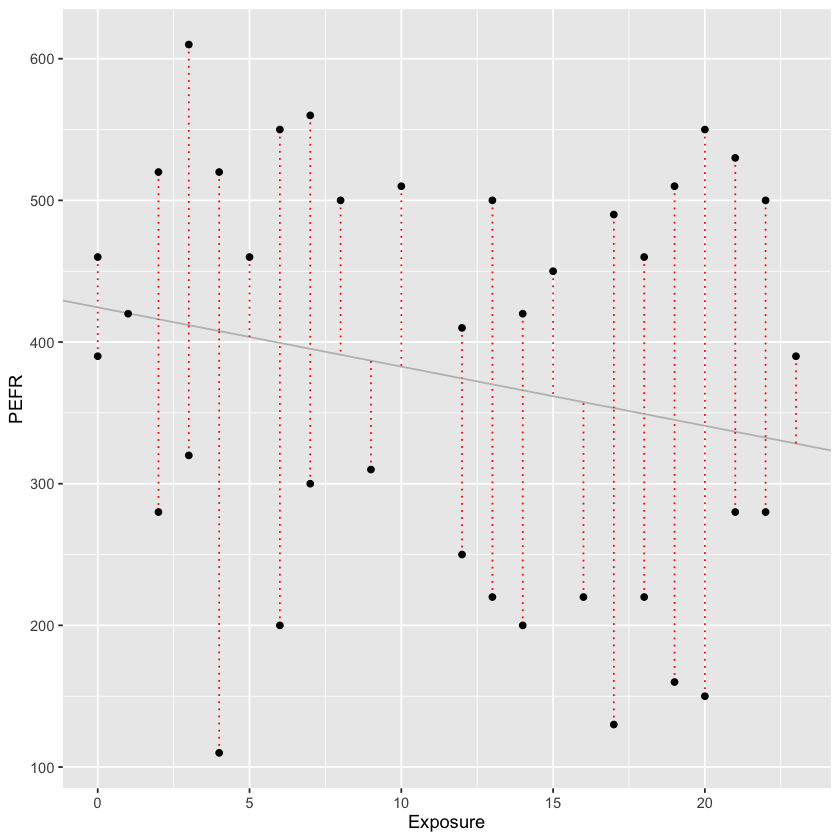

In [1]:
fitted <- predict(model)
resid <- residuals(model)

lung1 <- lung %>%
  mutate(
    Fitted = fitted,
    positive = PEFR > Fitted,
  ) %>%
  group_by(Exposure, positive) %>%
  summarize(
    PEFR_max = max(PEFR),
    PEFR_min = min(PEFR),
    Fitted = first(Fitted),
    .groups = "keep",
  ) %>%
  ungroup() %>%
  mutate(PEFR = ifelse(positive, PEFR_max, PEFR_min)) %>%
  arrange(Exposure)

ggplot(lung1, aes(x = Exposure, y = PEFR, xend = Exposure, yend = Fitted)) +
  geom_abline(intercept = model$coefficients[1], slope = model$coefficients[2],
    color = "grey") +
  geom_segment(linetype = 3, color = "red") +
  geom_point()

## Figure 4-5. An example of an influential data point in regression

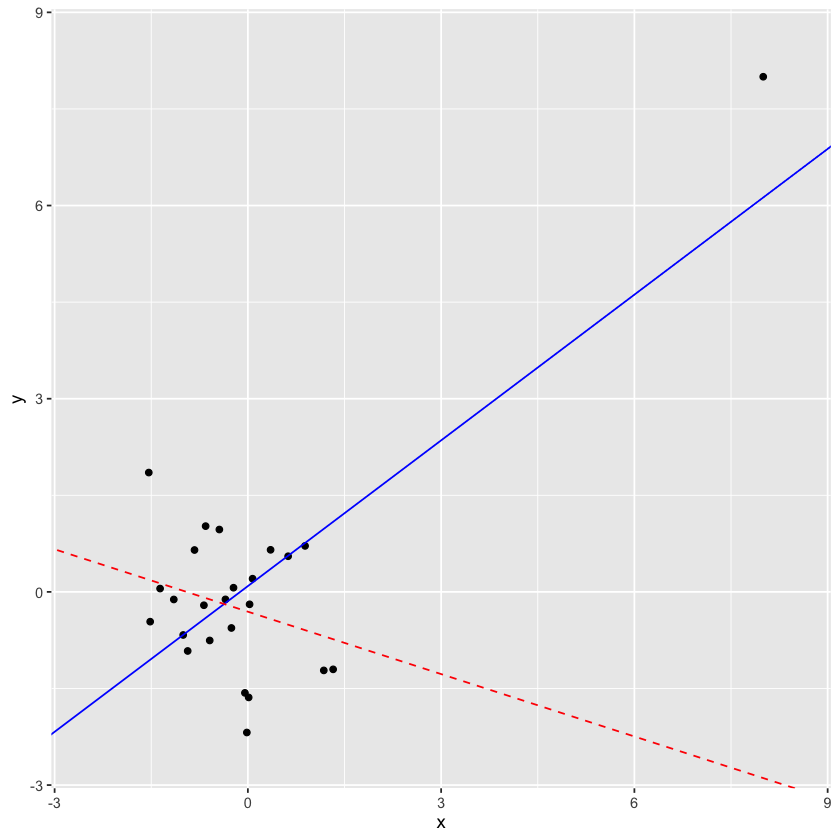

In [1]:
seed <- 11
set.seed(seed)

df <- tibble(
  x = rnorm(25),
  y = - x / 5 + rnorm(25)
)
df$x[1] <- 8
df$y[1] <- 8

model1 <- lm(y ~ x, data = df)
model2 <- lm(y[-1] ~ x[-1], data = df)

g <- ggplot(df, aes(x = x, y = y)) +
  geom_point() +
  coord_cartesian(xlim = c(-2.5, 8.5), ylim = c(-2.5, 8.5)) +
  geom_abline(intercept = model1$coefficients[1], slope = model1$coefficients[2],
    col = "blue") +
  geom_abline(intercept = model2$coefficients[1], slope = model2$coefficients[2],
    col = "red", linetype = 2)
g

## Figure 4-8. A histogram of the residuals from the regression of the housing data

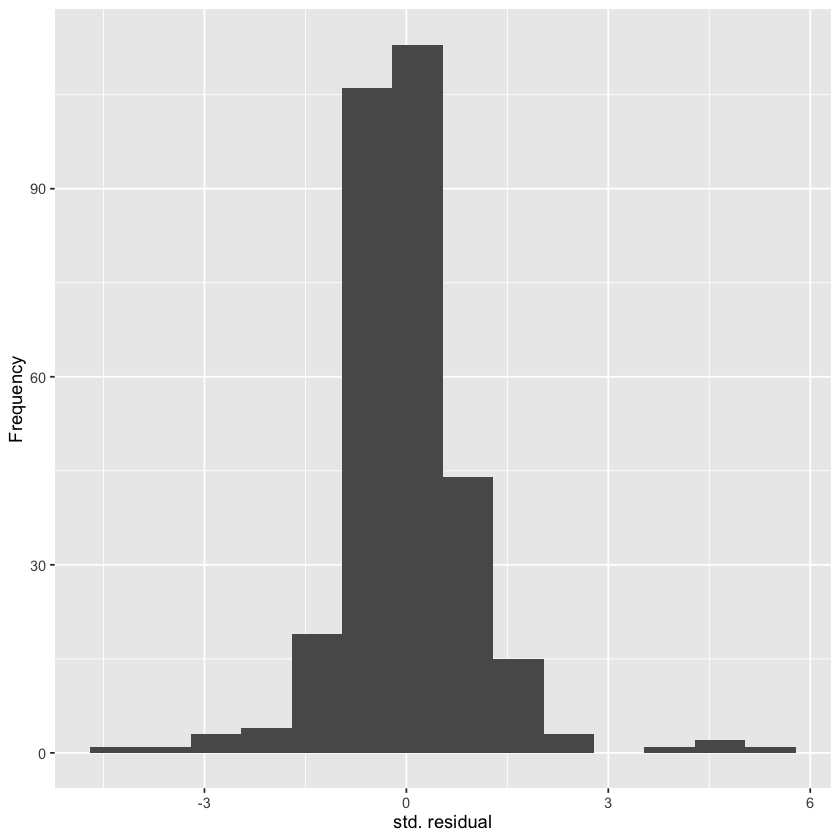

In [1]:
ggplot(tibble(x = df_influential$std_resid), aes(x = x)) +
  geom_histogram(bins = 14) +
  labs(x = "std. residual", y = "Frequency")

## Figure 4-10. A polynomial regression fit for the variable SqFtTotLiving
### (solid line) versus a smooth (dashed line; see the following section about splines)

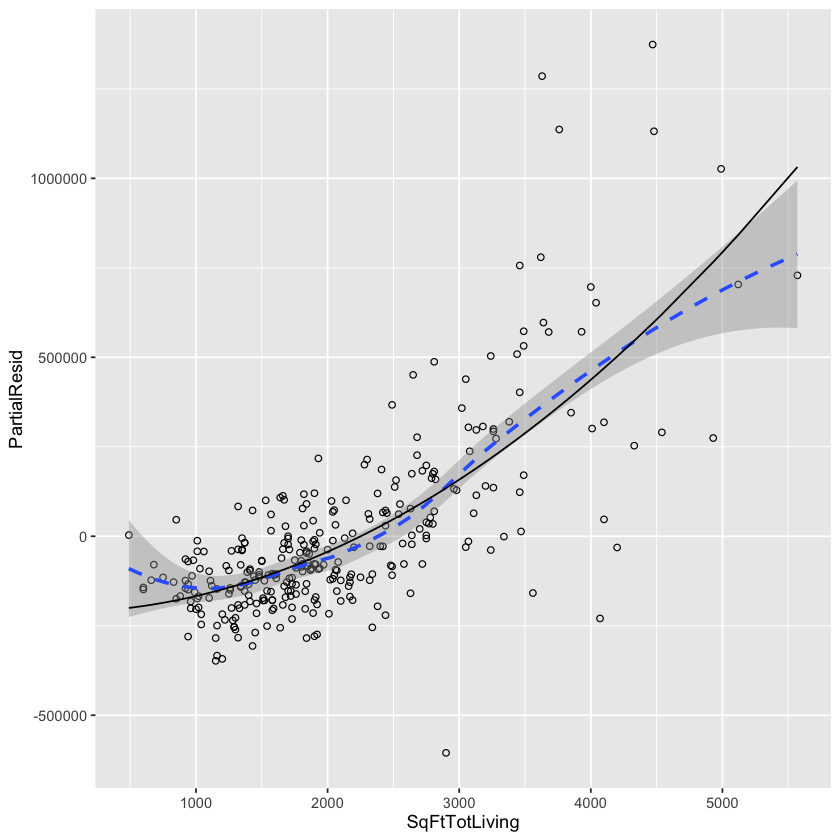

In [1]:
terms <- predict(lm_poly, type = "terms")
partial_resid <- resid(lm_poly) + terms
df <- data.frame(SqFtTotLiving = house_98105[, "SqFtTotLiving"],
  Terms = terms[, 1],
  PartialResid = partial_resid[, 1])
graph <- ggplot(df, aes(SqFtTotLiving, PartialResid)) +
  geom_point(shape = 1) +
  scale_shape(solid = FALSE) +
  geom_smooth(linetype = 2, formula = y ~ x, method = "loess") +
  geom_line(aes(SqFtTotLiving, Terms)) +
  scale_y_continuous(labels = function(x) format(x, scientific = FALSE))
graph

## Figure 4-12. A spline regression fit for the variable SqFtTotLiving (solid line) compared to a smooth (dashed line)

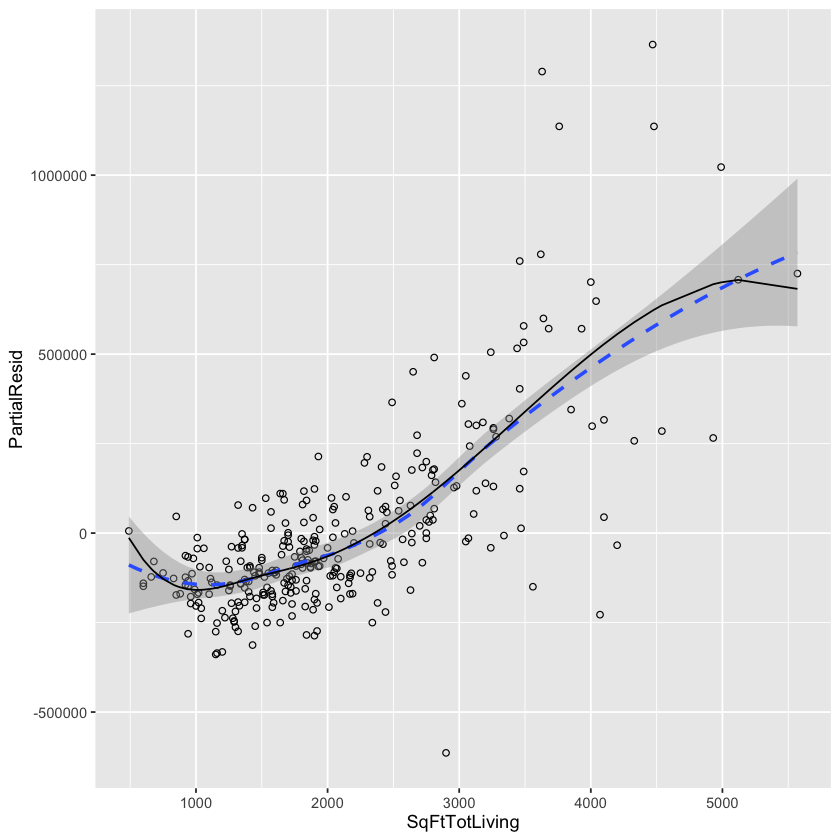

In [1]:
terms1 <- predict(lm_spline, type = "terms")
partial_resid1 <- resid(lm_spline) + terms1
df1 <- data.frame(SqFtTotLiving = house_98105[, "SqFtTotLiving"],
  Terms = terms1[, 1],
  PartialResid = partial_resid1[, 1])

graph <- ggplot(df1, aes(SqFtTotLiving, PartialResid)) +
  geom_point(shape = 1) +
  scale_shape(solid = FALSE) +
  geom_smooth(linetype = 2, formula = y ~ x, method = "loess") +
  geom_line(aes(SqFtTotLiving, Terms)) +
  scale_y_continuous(labels = function(x) format(x, scientific = FALSE))
graph

## Figure 4-13. A GAM regression fit for the variable SqFtTotLiving (solid line) compared to a smooth (dashed line)

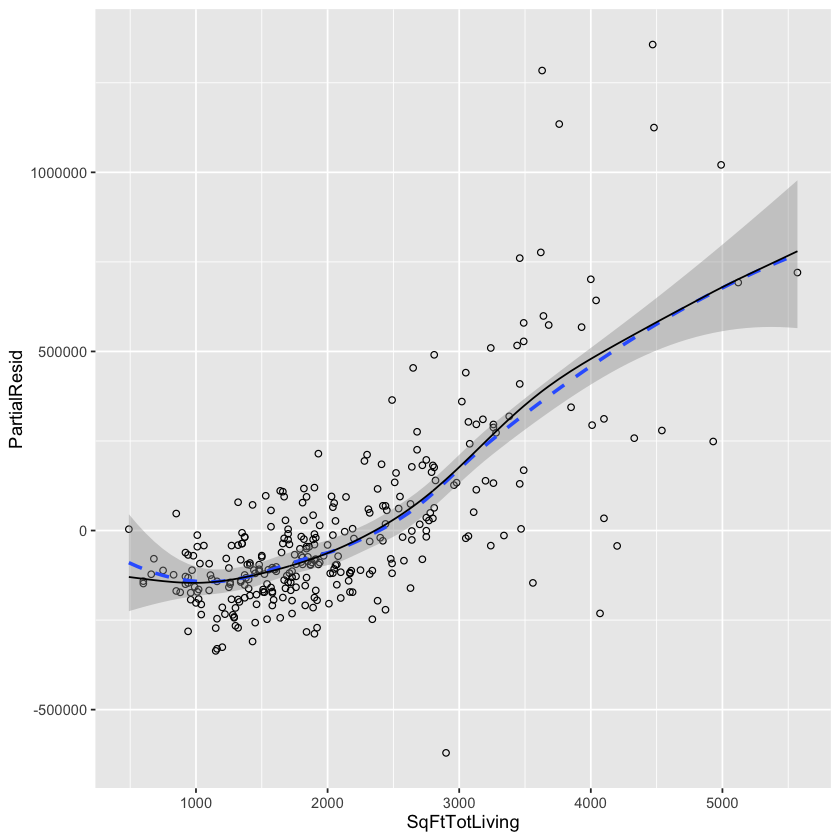

In [1]:
terms <- predict.gam(lm_gam, type = "terms")
partial_resid <- resid(lm_gam) + terms
df <- data.frame(SqFtTotLiving = house_98105[, "SqFtTotLiving"],
  Terms = terms[, 5],
  PartialResid = partial_resid[, 5])
graph <- ggplot(df, aes(SqFtTotLiving, PartialResid)) +
  geom_point(shape = 1) +
  scale_shape(solid = FALSE) +
  geom_smooth(linetype = 2, formula = y ~ x, method = "loess") +
  geom_line(aes(SqFtTotLiving, Terms)) +
  scale_y_continuous(labels = function(x) format(x, scientific = FALSE))
graph

## Generalized additive models using statsmodels

## Additional material not covered in book
### Regularization - Lasso